In [ ]:
!pip install bertopic
!pip install sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 92.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 107.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-

In [ ]:
import pandas as pd
import numpy as np
from bertopic import BERTopic
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from collections import defaultdict
from sentence_transformers import SentenceTransformer

In [ ]:
# gunakan embedding model dari IndoBERT
embedding_model = SentenceTransformer("indobenchmark/indobert-base-p1")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
# import data
df = pd.read_csv('/content/result_2.csv')
df

# filter
df_filtered = df[df['title'] == 'RS Triharsi']
display(df_filtered)

,title,stars,text,bin_pelayanan,bin_fasilitas,predicted_labels_1,labels,prob_layanan,prob_fasilitas
6366,RS Triharsi,5,rs triharsi salah satu rs terbaik di solo,1,1,"['pelayanan', 'fasilitas']",positive,0.879705,0.871471
6367,RS Triharsi,5,selama saya jadi pasien di rs tri harsi itu pe...,1,1,"['pelayanan', 'fasilitas']",negative,0.999000,0.694225
6368,RS Triharsi,5,pelayanann ramah obat antri tidak lama namun m...,1,1,"['pelayanan', 'fasilitas']",positive,0.997877,0.952121
6369,RS Triharsi,5,tempatnya nyaman dan secara umum pelayanan oke,1,1,"['pelayanan', 'fasilitas']",positive,0.996106,0.989550
6370,RS Triharsi,5,pelayanan nya sangat fasilitas sesuai kelas ny...,1,1,"['pelayanan', 'fasilitas']",positive,0.996982,0.988619
...,...,...,...,...,...,...,...,...,...
7143,RS Triharsi,5,rumah sakit ini menerima pasien bpjspelayanann...,1,1,"['pelayanan', 'fasilitas']",positive,0.999284,0.752675
7144,RS Triharsi,5,ambulans ready dan satpam stanby terus,1,0,['pelayanan'],neutral,0.998855,0.377397
7145,RS Triharsi,4,renovasi jadi baru,0,1,['fasilitas'],negative,0.003792,0.986556
7146,RS Triharsi,4,tidak sebanyak,1,1,"['pelayanan', 'fasilitas']",negative,0.981142,0.981596


In [ ]:
# menghapus stopwords
import re

# daftar
stopwords = ['saya', 'yg', 'dan', 'yang', 'di', 'tidak', 'juga', 'utk', 'itu',
             'untuk', 'juga', 'jg', 'nya', 'tapi', 'tp', 'ga', 'gak', 'ngga', 'nggak', 'sy', 'lagi',
             'lg', 'dengan', 'dgn', 'dg', 'ini', 'kami', 'apa', 'ada', 'ke', 'ya', 'dong', 'sgt', 'bgt',
             'karena', 'krn', 'sebagai', 'sbg', 'dari', 'malah']

# function
def remove_stopwords(text):
    if isinstance(text, str):  # make sure string
        pattern = r'\b(?:' + '|'.join(stopwords) + r')\b'
        return re.sub(pattern, '', text, flags=re.IGNORECASE).strip()
    return text


df_filtered['text'] = df_filtered['text'].apply(remove_stopwords)

# Kategori

In [ ]:
# insialisasi model untuk dua kategori
layanan_model = BERTopic(embedding_model=embedding_model, min_topic_size=10, nr_topics=5)
fasilitas_model = BERTopic(embedding_model=embedding_model, min_topic_size=10, nr_topics=5)

In [ ]:
# Fungsi untuk memisahkan ulasan berdasarkan probabilitas kategori
def assign_reviews_by_category(data, threshold=0.5):
    layanan_reviews = []
    fasilitas_reviews = []
    layanan_indices = []
    fasilitas_indices = []
    for idx, row in data.iterrows():
        if row['prob_layanan'] >= threshold:
            layanan_reviews.append(row['text'])
            layanan_indices.append(idx)
        if row['prob_fasilitas'] >= threshold:
            fasilitas_reviews.append(row['text'])
            fasilitas_indices.append(idx)
    return layanan_reviews, fasilitas_reviews, layanan_indices, fasilitas_indices

# Memisahkan ulasan (ulasan dengan prob 0.99 masuk ke kedua kategori)
layanan_reviews, fasilitas_reviews, layanan_indices, fasilitas_indices = assign_reviews_by_category(df_filtered, threshold=0.5)

In [ ]:
# Pemodelan topik untuk kategori layanan
if layanan_reviews:
    topics_layanan, probs_layanan = layanan_model.fit_transform(layanan_reviews)
else:
    topics_layanan, probs_layanan = [], []

In [ ]:
# Pemodelan topik untuk kategori fasilitas
if fasilitas_reviews:
    topics_fasilitas, probs_fasilitas = fasilitas_model.fit_transform(fasilitas_reviews)
else:
    topics_fasilitas, probs_fasilitas = [], []

In [ ]:
# layanan_model.update_topics(layanan_reviews, top_n_words=10)  # Batasi ke 10 kata
# fasilitas_model.update_topics(fasilitas_reviews, top_n_words=10)  # Batasi ke 10 kata

## Hasil topic modelling

In [ ]:
# melihat total topic layanan
print(len(layanan_model.get_topics()))

# melihat total topic fasilitas
print(len(fasilitas_model.get_topics()))

3
2


In [ ]:
layanan_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,0,577,0_rs_pelayanan_triharsi_ramah,"[rs, pelayanan, triharsi, ramah, dokter, sanga...","[pelayanan baik RS TriHarsi, rs pelayanan ..."
1,1,23,1_bagus_baik_tempat_sangat,"[bagus, baik, tempat, sangat, sulitnya, keberh...","[bagus, Bagus, bagus]"
2,2,134,2_pelayanan_bagus_ramah_baik,"[pelayanan, bagus, ramah, baik, sangat, memuas...","[pelayanan baik ramah, sangat bagus pelayanan..."


In [ ]:
fasilitas_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,0,19,0_bagus_baik_biasaa_stabil,"[bagus, baik, biasaa, stabil, sebanyak, senang...","[bagus, bagus, Bagus]"
1,1,317,1_pelayanan_ramah_bersih_rs,"[pelayanan, ramah, bersih, rs, sangat, pasien,...",[rs bersih pelayanan bagus sangat sangat rama...


## Frekuensi sentimen dari setiap topik

In [ ]:
import numpy as np
import pandas as pd

# === Analisis Topik & Sentimen untuk Layanan ===
# Pastikan indeks valid
layanan_indices_valid = np.intersect1d(layanan_indices, df_filtered.index)

df_layanan = df_filtered.loc[layanan_indices_valid].copy()
df_layanan["topic"] = topics_layanan[:len(df_layanan)]  # pastikan panjang sama

df_layanan = df_layanan[df_layanan['topic'] != -1]
topic_sentiment_layanan = pd.crosstab(df_layanan['topic'], df_layanan['labels'])
emotion_dist_layanan = pd.crosstab(df_layanan['topic'], df_layanan['labels'], normalize='index')

print("=== Distribusi Sentimen per Topik (Layanan) ===")
print(topic_sentiment_layanan)
print("\n=== Proporsi Sentimen per Topik (Layanan) ===")
print(emotion_dist_layanan)


# === Analisis Topik & Sentimen untuk Fasilitas ===
# Pastikan indeks valid
fasilitas_indices_valid = np.intersect1d(fasilitas_indices, df_filtered.index)

df_fasilitas = df_filtered.loc[fasilitas_indices_valid].copy()
df_fasilitas["topic"] = topics_fasilitas[:len(df_fasilitas)]  # pastikan panjang sama

df_fasilitas = df_fasilitas[df_fasilitas['topic'] != -1]
topic_sentiment_fasilitas = pd.crosstab(df_fasilitas['topic'], df_fasilitas['labels'])
emotion_dist_fasilitas = pd.crosstab(df_fasilitas['topic'], df_fasilitas['labels'], normalize='index')

print("\n=== Distribusi Sentimen per Topik (Fasilitas) ===")
print(topic_sentiment_fasilitas)
print("\n=== Proporsi Sentimen per Topik (Fasilitas) ===")
print(emotion_dist_fasilitas)


=== Distribusi Sentimen per Topik (Layanan) ===
labels  negative  neutral  positive
topic                              
0            135       37       405
1              2        2        19
2              9        1       124

=== Proporsi Sentimen per Topik (Layanan) ===
labels  negative   neutral  positive
topic                               
0       0.233969  0.064125  0.701906
1       0.086957  0.086957  0.826087
2       0.067164  0.007463  0.925373

=== Distribusi Sentimen per Topik (Fasilitas) ===
labels  negative  neutral  positive
topic                              
0              1        1        17
1             62       11       244

=== Proporsi Sentimen per Topik (Fasilitas) ===
labels  negative   neutral  positive
topic                               
0       0.052632  0.052632  0.894737
1       0.195584  0.034700  0.769716


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

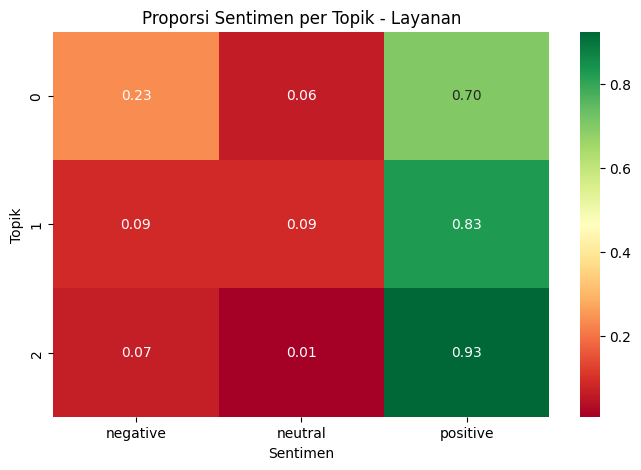

In [ ]:
# Heatmap proporsi (Layanan)
plt.figure(figsize=(8, 5))
sns.heatmap(emotion_dist_layanan, annot=True, fmt=".2f", cmap="RdYlGn")
plt.title("Proporsi Sentimen per Topik - Layanan")
plt.ylabel("Topik")
plt.xlabel("Sentimen")
plt.show()

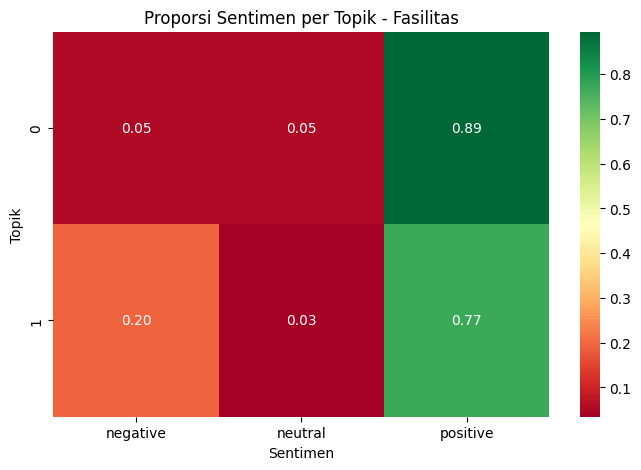

In [ ]:
# Heatmap proporsi (Layanan)
plt.figure(figsize=(8, 5))
sns.heatmap(emotion_dist_fasilitas, annot=True, fmt=".2f", cmap="RdYlGn")
plt.title("Proporsi Sentimen per Topik - Fasilitas")
plt.ylabel("Topik")
plt.xlabel("Sentimen")
plt.show()

In [ ]:
# Fungsi untuk menampilkan kata kunci tiap topik
def tampilkan_topik(model, kategori):
    topics = model.get_topics()
    print(f"=== Topik untuk kategori {kategori} ===")
    for topic_id, topic_info in topics.items():
        print(f"Topic {topic_id}:")
        print(f"Representasi: {topic_info}")
        print("-" * 50)
    print("\n")

# Panggil untuk layanan dan fasilitas
tampilkan_topik(layanan_model, "Layanan")
tampilkan_topik(fasilitas_model, "Fasilitas")

=== Topik untuk kategori Layanan ===
Topic 0:
Representasi: [('rs', np.float64(0.057826599219248966)), ('pelayanan', np.float64(0.05710526144602501)), ('triharsi', np.float64(0.05129585974358273)), ('ramah', np.float64(0.05076257762284942)), ('dokter', np.float64(0.04709171474159268)), ('sangat', np.float64(0.04690553786898615)), ('pasien', np.float64(0.04426848648046319)), ('baik', np.float64(0.04193559836420986)), ('perawat', np.float64(0.03454128814080225)), ('sakit', np.float64(0.03408604478931306))]
--------------------------------------------------
Topic 1:
Representasi: [('bagus', np.float64(0.6496261693600612)), ('baik', np.float64(0.24601577957218762)), ('tempat', np.float64(0.24238712389624295)), ('sangat', np.float64(0.23635105377836155)), ('sulitnya', np.float64(0.22590731416373247)), ('keberhasilan', np.float64(0.22590731416373247)), ('biasaa', np.float64(0.22590731416373247)), ('sebanyak', np.float64(0.207671519104508)), ('tlp', np.float64(0.1970063039795248)), ('stabil',

# Sentimen

In [ ]:
# insialisasi model untuk dua sentimen
positive_model = BERTopic(embedding_model=embedding_model, min_topic_size=10, nr_topics=8)
negative_model = BERTopic(embedding_model=embedding_model, min_topic_size=10, nr_topics=6)

In [ ]:
# Fungsi untuk memisahkan ulasan berdasarkan sentimen
def assign_reviews_by_sentiment(data):
    positif_reviews = data[data['labels'] == 'positive']['text'].tolist()
    negatif_reviews = data[data['labels'] == 'negative']['text'].tolist()
    positif_indices = data[data['labels'] == 'positive'].index.tolist()
    negatif_indices = data[data['labels'] == 'negative'].index.tolist()
    return positif_reviews, negatif_reviews, positif_indices, negatif_indices

In [ ]:
# Memisahkan ulasan berdasarkan sentimen
positif_reviews, negatif_reviews, positif_indices, negatif_indices = assign_reviews_by_sentiment(df_filtered)

In [ ]:
# Pemodelan topik untuk sentimen positif
if positif_reviews:
    topics_positif, probs_positif = positive_model.fit_transform(positif_reviews)
else:
    topics_positif, probs_positif = [], []

In [ ]:
# Pemodelan topik untuk sentimen negatif
if negatif_reviews:
    topics_negatif, probs_negatif = negative_model.fit_transform(negatif_reviews)
else:
    topics_negatif, probs_negatif = [], []

## Hasil Topic Modelling

In [ ]:
# melihat total topic positive
print(len(positive_model.get_topics()))

# melihat total topic negative
print(len(negative_model.get_topics()))

6
3


In [ ]:
positive_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,3,-1_optimal_disemua_tinggi_lini,"[optimal, disemua, tinggi, lini, memuaskan, ge...","[respon layanan cepat ramah memuaskan, temp..."
1,0,416,0_rs_triharsi_pelayanan_ramah,"[rs, triharsi, pelayanan, ramah, sangat, baik,...",[rs pelayanan sangat baik dokter perawat sam...
2,1,21,1_bagus_biasaa_putranya_keberhasilan,"[bagus, biasaa, putranya, keberhasilan, stabil...","[Bagus, bagus, bagus]"
3,2,11,2_bersih_nyaman_nyamandokter_nyamanbersih,"[bersih, nyaman, nyamandokter, nyamanbersih, n...","[tempat bersih nyaman, bersih nyaman, nyaman ..."
4,3,74,3_pelayanan_bagus_baik_pelayanannya,"[pelayanan, bagus, baik, pelayanannya, sangat,...","[pelayanan sangat baik, pelayanan sangat baik,..."
5,4,49,4_pelayanan_bagus_ramah_bersih,"[pelayanan, bagus, ramah, bersih, tempat, nyam...","[tempat nyaman pelayanan baik ramah, pelayana..."


In [ ]:
negative_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,11,-1_parkir_tarif_mohon_hanya,"[parkir, tarif, mohon, hanya, pria, org, buruk...",[pelayanan sangat buruk menunggu resep obat dr...
1,0,16,0_kurang_pelayanan_baik_parkir,"[kurang, pelayanan, baik, parkir, satpam, bagu...","[kurang bagus pelayananwaktu parkir, bagus pel..."
2,1,126,1_pasien_dokter_pelayanan_jam,"[pasien, dokter, pelayanan, jam, rs, sudah, sa...",[sebelum kesini nyempatin baca ulasan badrevie...


In [ ]:
# Panggil untuk layanan dan fasilitas
tampilkan_topik(positive_model, "Positif")
tampilkan_topik(negative_model, "Negatif")

=== Topik untuk kategori Positif ===
Topic -1:
Representasi: [('optimal', np.float64(0.4349340170651621)), ('disemua', np.float64(0.4349340170651621)), ('tinggi', np.float64(0.39419681921524075)), ('lini', np.float64(0.39419681921524075)), ('memuaskan', np.float64(0.3904988558104105)), ('gedungnya', np.float64(0.3534957204401267)), ('respon', np.float64(0.32971700784664465)), ('besar', np.float64(0.32971700784664465)), ('luas', np.float64(0.2801637793605042)), ('layanan', np.float64(0.2623793292029226))]
--------------------------------------------------
Topic 0:
Representasi: [('rs', np.float64(0.053512015261428215)), ('triharsi', np.float64(0.05248941980494738)), ('pelayanan', np.float64(0.05061497223095141)), ('ramah', np.float64(0.04945860005364735)), ('sangat', np.float64(0.04560739653041433)), ('baik', np.float64(0.04132708106184022)), ('dokter', np.float64(0.03955677314377829)), ('pasien', np.float64(0.033574828404332166)), ('perawat', np.float64(0.033272352472761606)), ('rumah'